In [93]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import jit, vmap, grad
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from jax import random
import jax
import time
from tqdm import tqdm
jax.config.update("jax_enable_x64", True)

In [94]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, input_dim, hidden_dim):
  subkey1, subkey2 = random.split(key)
  params = {
      'W1': random.normal(subkey1, (hidden_dim, input_dim)) * 1.0,
      'b1': jnp.zeros(hidden_dim),
      'W2': random.normal(subkey2, (1, hidden_dim)) * 1.0,
      'b2': jnp.zeros(1),
  }
  return params

@jit
def forward(params, z):
  h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  # h = jax.nn.elu(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
  return y.squeeze()

def forward_(X, z, unravel_fn):
  E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
  return E

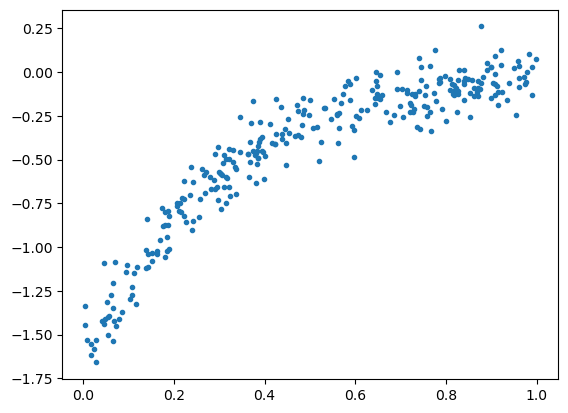

In [95]:
def target_function(z):
  # params = jnp.array([2, -0.5, 3, -3])
  # return params[2]*jnp.tanh(params[0]*z.squeeze()-params[1]) + params[3]
  params = jnp.array([2, 0.5, 3, -3])
  return params[2]*jnp.tanh(params[0]*z.squeeze()+params[1]) + params[3]
  # return z.squeeze()**2
  # return jnp.sin(2 * jnp.pi * z.squeeze())#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]
    Y_clean = target_function(Z)
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y = Y_clean + noise
    return Z, Y

s = 1 #input dimension
key = random.PRNGKey(1003)
key, subkey = random.split(key)
N = 300
Z, Y = generate_data(subkey, s, N=N, noise_std=0.1) # put more noise
device = jax.devices()[0]
Z, Y = jax.device_put((Z, Y), device)
plt.plot(Z,Y,".")

In [110]:
from functools import partial
def log_q0(x, cov=0.5):
  return multivariate_normal.logpdf(x, jnp.zeros_like(x), cov)

def L(X, unravel_fn, gamma=100):
    Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
    return gamma * jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

def gL(X, unravel_fn, gamma):
  Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
  # x = X[0]
  g = jax.grad(lambda x, z: forward(unravel_fn(x), z), 0)
  # print(g(x, Z[0]).shape)
  G = vmap( lambda x: vmap(lambda z: g(x, z))(Z) )(X)
  # print(G.shape)
  diff= ( Y -Esp_forward )[:, None]
  result = vmap(lambda i: (diff * G[i]).mean(axis=0))(jnp.arange(len(X)))
  # print(result.shape)
  return -2*gamma * result

# This part is required to obtain unravel_fn
hidden_dim = 1
params = init_params(key, s, hidden_dim)
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)

# q0cov = 100.
# log_q0_ = lambda x: log_q0(x, q0cov)
gamma = 300
L_ = jit(lambda X: L(X, unravel_fn, gamma))
S_q0 = jit(vmap(grad(log_q0)))
# gradL = jit(grad(lambda X : L_(X)* len(X)))
gradL = jit(lambda X : gL(X, unravel_fn, gamma))
score = lambda X: S_q0(X) - gradL(X)

In [111]:
class GradientKernel:
    def __init__(self, S_PQ, k):
        self.S_PQ = S_PQ
        self.k = jit(k)
        self.dkx = jit(jacrev(self.k, argnums=0))
        self.dky = jit(jacrev(self.k, argnums=1))
        self.d2k = jit(jacfwd(self.dky, argnums=0))
        self.K = lambda X : vmap(lambda x: vmap(lambda y: self.k(x, y))(X))(X)
        self.dKx = lambda X : vmap(lambda x: vmap(lambda y: self.dkx(x, y))(X))(X)
        self.d2K = lambda X : vmap(lambda x: vmap(lambda y: jnp.trace(self.d2k(x, y)))(X))(X)


    def evaluate(self, X):
        K = self.K(X)
        dK = self.dKx(X)
        d2K = self.d2K(X)
        S_PQ = self.S_PQ(X)
        S_dK = jnp.einsum('ijk, jk -> ij', dK, S_PQ)
        k_pq = d2K + S_dK + S_dK.T + K * (S_PQ @ S_PQ.T)
        return k_pq


def kgd(k_pq, X):
  return k_pq.evaluate(X).mean()

def k_imq(x, y, c, b, scale=1.):
  assert b > 0
  return (c**2 + (x-y).dot(x-y)/scale**2)**(-b)

def imq_scale_mixtures(x, y, scales):
  return  vmap(lambda scale: k_imq(x, y, 1, 0.5, scale))(scales).mean()

In [112]:
# Kernels
scale = 1e-0
# k = lambda x, y: jnp.exp(-((x-y).dot(x-y)/scale**2))
# k = jit(lambda x, y: k_imq(x/scale, y/scale, 1, 0.5) + x.dot(y))
k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))
# k = jit(lambda x, y: imq_scale_mixtures(x, y, jnp.logspace(-2, 2, 5)))
# k = lambda x, y: (1 + x.dot(y))**2
k_pq = GradientKernel(score, k)

In [113]:
import flax
from flax import linen as nn

# Pushforward map
class Model(nn.Module):
    hidden_dim: int
    output_dim: int = 1

    @nn.compact
    def __call__(self, x):
        # return nn.Dense(self.output_dim)(x).squeeze()
        y = nn.Dense(self.hidden_dim)(x)
        y = nn.elu(y)
        y = nn.Dense(self.hidden_dim)(y)
        y = nn.elu(y)
        y = nn.Dense(self.hidden_dim)(y)
        y = nn.elu(y)
        y = nn.Dense(self.output_dim)(y)
        return  y.squeeze() #+x #  + nn.Dense(self.output_dim)(x)

def l2_norm(params):
    # sum of squared parameters over the whole pytree
    return sum([jnp.sum(jnp.square(p)) for p in jax.tree_util.tree_leaves(params)])

def loss(key, params, num_samples=100, d_noise=10, reg=1e+0
         ):
  noise = noise_fn(key, (num_samples, d_noise))
  X = model.apply(params, noise)
  K = k_pq.evaluate(X)
  K_diag = jnp.diag(K)
  K = K - jnp.diag(K_diag)
  return K.mean() + reg*l2_norm(params)
  # return L_(X)/gamma
  # return K.mean()**0.5   + reg*l2_norm(params)

def pretraining_loss(key, params, n_sample=100, init_std=3):
  key1, key2 = random.split(key)
  noise = noise_fn(key1, (n_sample, d_noise))
  X = model.apply(params, noise)
  # return L_(X) / gamma
  target_samples = init_std*random.normal(key2, X.shape)
  assert target_samples.shape == X.shape
  # k = lambda x, y: k_imq(x, y, 1, 0.5, 1)
  k = lambda x, y: imq_scale_mixtures(x, y, jnp.logspace(-2, 2, 5))
  Kxx = vmap(lambda x: vmap(lambda y: k(x, y))(X))(X)
  Kxy = vmap(lambda x: vmap(lambda y: k(x, y))(target_samples))(X)
  Kyy = vmap(lambda x: vmap(lambda y: k(x, y))(target_samples))(target_samples)
  # Kxx = vmap( lambda x: vmap(lambda y: imq_scale_mixtures(x, y, scales=jnp.logspace(-2, 2, 5)))(X))(X)
  # Kxy = vmap( lambda x: vmap(lambda y: imq_scale_mixtures(x, y, scales=jnp.logspace(-2, 2, 5)))(target_samples))(X)
  return (Kxx - 2*Kxy + Kyy).mean()

def noise_fn(key, shape):
  #return random.normal(key, shape)
  return random.uniform(key, shape, minval=-5, maxval=5)

  2%|▎         | 25/1000 [00:00<00:14, 68.28it/s]

Pretraining step: 0, Loss: 0.0482419620426222


 14%|█▍        | 143/1000 [00:00<00:04, 202.60it/s]

Pretraining step: 100, Loss: 0.01549505074075612


 24%|██▍       | 240/1000 [00:01<00:03, 226.63it/s]

...

 99%|█████████▉| 19817/20000 [03:07<00:01, 106.47it/s]

Step 19800, Loss: 31.76098136975635, MSE 0.016897417399391036, Grad 2.462760765100533


100%|█████████▉| 19916/20000 [03:08<00:00, 105.81it/s]

Step 19900, Loss: 8.508566610002742, MSE 0.017860341747030162, Grad 3.5327672133245738


100%|██████████| 20000/20000 [03:09<00:00, 105.44it/s]


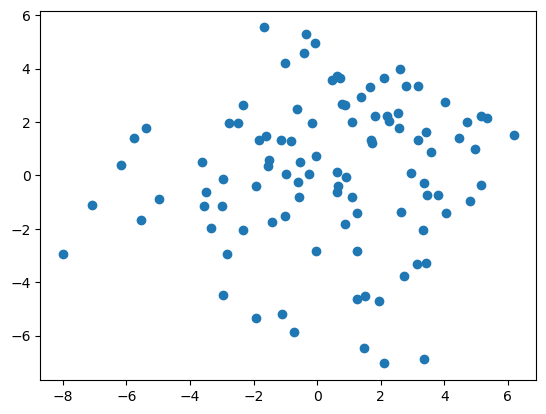

In [114]:
model = Model(20, d)
d_noise = d

# initialisation
key1, key2 = random.split(random.key(0))
x = random.normal(key1, (d_noise,)) # Dummy input data
params = model.init(key2, x) # Initialization call
jax.tree_util.tree_map(lambda x: x.shape, params) # Checking output shapes
model.apply(params, x)

import optax

learning_rate = 1e-3        # SGD usually needs a bigger LR than Adam; try 1e-2 → 1e-1
# tx = optax.sgd(learning_rate=learning_rate, momentum=0.0)   # momentum=0 → pure GD
# or: tx = optax.sgd(learning_rate=learning_rate, momentum=0.9)  # classic SGD+momentum
# learning_rate = 5e-3
tx = optax.adam(learning_rate=learning_rate)
opt_state = tx.init(params)



# Training loop
T_pretrain = 1000
key, *(keys) = random.split(key, T_pretrain+1)
# pretraining
pretraining_loss_ = jit(pretraining_loss)
for step in tqdm(range(T_pretrain)):
    loss_grad_fn = jax.value_and_grad(lambda params: pretraining_loss_(keys[step], params))
    loss_value, grads = loss_grad_fn(params)
    updates, opt_state = tx.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    if step % 100 == 0:
      print("Pretraining step: {}, Loss: {}".format(step, loss_value))
print("Pretraining done. Loss: {}".format(loss_value))
#print(X.shape)
X = model.apply(params, noise_fn(key, (100, d_noise)))
plt.scatter(X[:,0],X[:,1])

learning_rate = 1e-3
# tx = optax.sgd(learning_rate=learning_rate, momentum=0.0)
# tx = optax.adam(learning_rate=learning_rate)
schedule = optax.exponential_decay(
    init_value=learning_rate,   # initial lr
    transition_steps=100,
    decay_rate=0.99
)
tx = optax.chain(
    # optax.clip(10.0),
    optax.adam(learning_rate=learning_rate),
    # optax.scale_by_learning_rate(schedule),
)
opt_state = tx.init(params)

T = 20000
num_particles = 100
losses = []
N = 2000
noise = noise_fn(key, (N, d_noise))
initial_particles = model.apply(params, noise)

keys = random.split(key, T)
loss_ = jit(lambda key, params: loss(key, params, num_samples=num_particles, d_noise=d_noise, reg=0))
KGD_values = []
for step in tqdm(range(T)):
    loss_grad_fn = jax.value_and_grad(lambda params: loss_(keys[step], params))
    loss_value, grads = loss_grad_fn(params)
    losses.append(loss_value)

    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    
    noise_kgd = noise_fn(subkey, (100, d_noise))
    X_kgd = model.apply(params, noise_kgd)
    KGD_values.append(jnp.sqrt(kgd(k_pq, X_kgd)))
    

    if step % 100 == 0:
      X = model.apply(params, noise)
      mse = L_(X) / gamma
      gradsize = (gradL(X)**2).sum() / gamma**2
      print(f"Step {step}, Loss: {loss_value}, MSE {mse}, Grad {gradsize}")




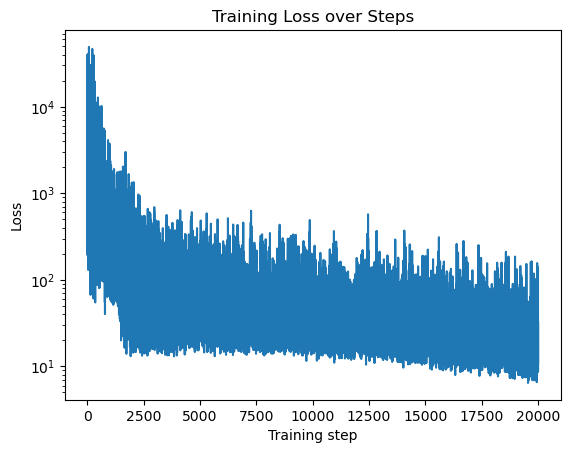

In [115]:
plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.yscale('log')
plt.title("Training Loss over Steps")
plt.show()

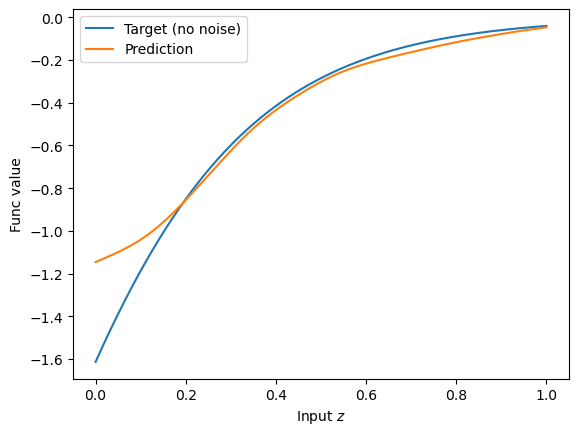

In [116]:
key, subkey = random.split(key)
N = 100
noise = noise_fn(subkey, (N, d_noise))
final_particles = model.apply(params, noise)
ntestpoints = 400
Ztest = jnp.linspace(0, 1, ntestpoints).reshape(-1, 1)
target_values = target_function(Ztest)
prediction = vmap(lambda z: forward_(final_particles, z, unravel_fn))(Ztest)

plt.plot(Ztest, target_values, label='Target (no noise)')
plt.plot(Ztest, prediction, label='Prediction')
plt.xlabel('Input $z$')
plt.ylabel('Func value')
# plt.title('Learned function for step size eta: {0:.3e}'.format(etas[i_eta]))
plt.legend()
plt.show()

In [117]:
gradL(initial_particles).std(axis=0)/gamma

Array([3.34601036e-01, 9.07089258e-01, 1.36074045e+00, 1.13686838e-15],      dtype=float64)

In [118]:
gradL(final_particles).mean(axis=0)/gamma

Array([0.00054079, 0.0027173 , 0.00390937, 0.02501858], dtype=float64)

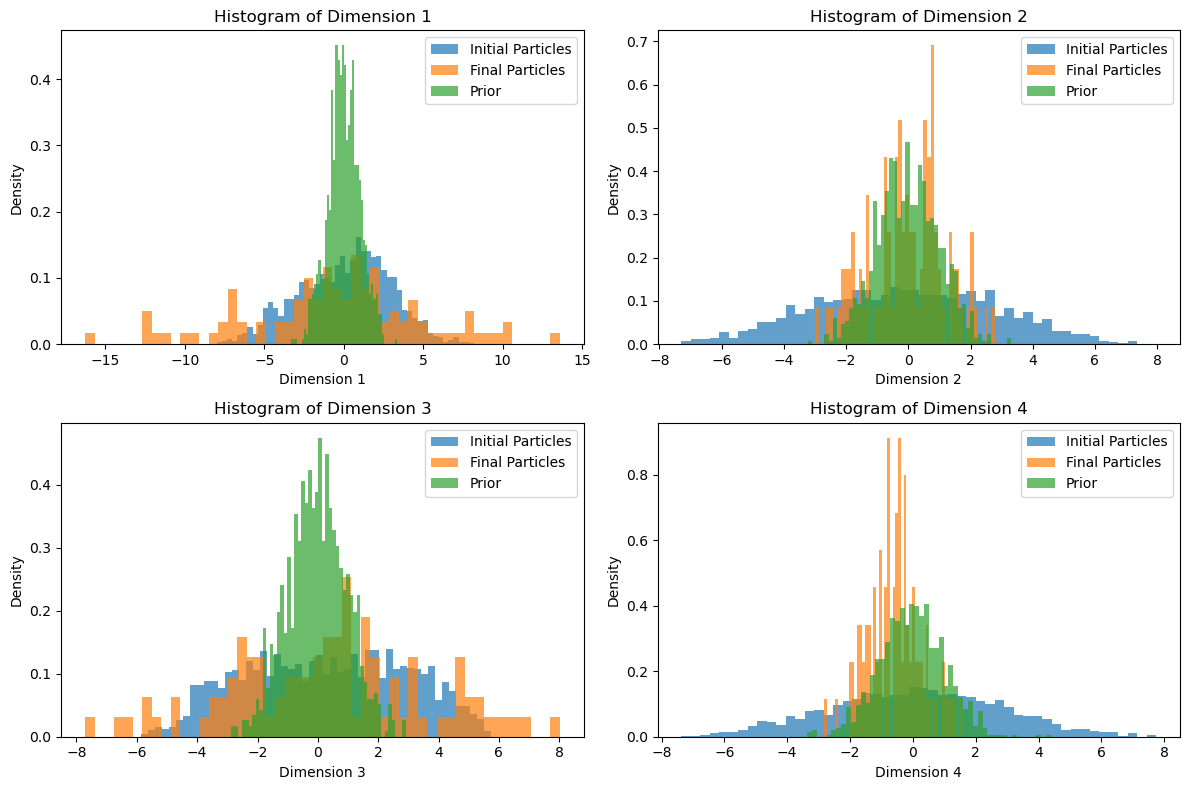

In [119]:
plt.figure(figsize=(12, 8))

key, subkey = random.split(key)
N = 1000
Q0_samples = random.normal(subkey, (N, d))


for i in range(final_particles.shape[1]):
    plt.subplot(2, 2, i + 1)
    plt.hist(initial_particles[:, i], bins=50, density=True, alpha=0.7, label='Initial Particles')
    plt.hist(final_particles[:, i], bins=50, density=True, alpha=0.7, label='Final Particles')
    plt.hist(Q0_samples[:, i], bins=50, density=True, alpha=0.7, label='Prior')

    plt.xlabel(f'Dimension {i + 1}')
    plt.ylabel('Density')
    plt.title(f'Histogram of Dimension {i + 1}')
    plt.legend()

plt.tight_layout()
plt.show()

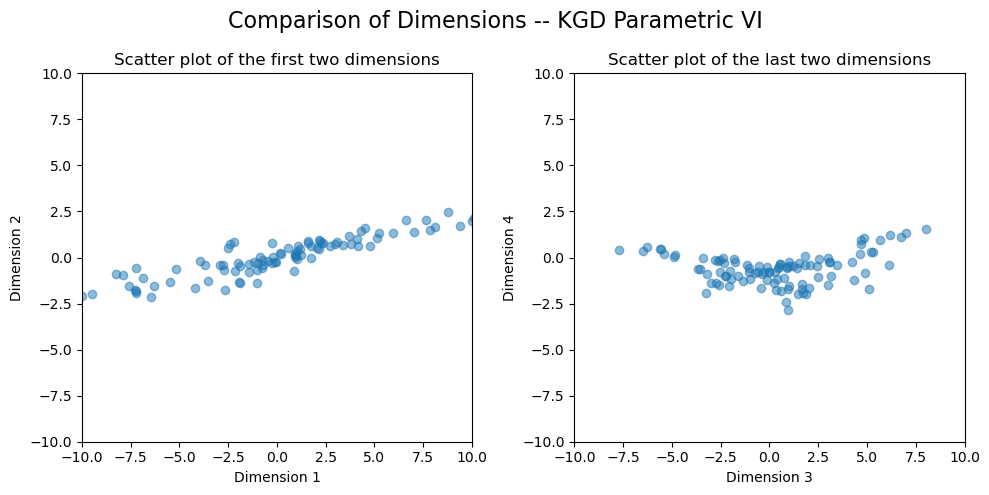

In [120]:
F = final_particles
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# First scatter plot
axes[0].scatter(F[:, 0], F[:, 1], alpha=0.5)
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-10, 10)
axes[0].set_xscale('linear')
axes[0].set_yscale('linear')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].set_title('Scatter plot of the first two dimensions')

# Second scatter plot
axes[1].scatter(F[:, 2], F[:, 3], alpha=0.5)
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(-10, 10)
axes[1].set_xscale('linear')
axes[1].set_yscale('linear')
axes[1].set_xlabel('Dimension 3')
axes[1].set_ylabel('Dimension 4')
axes[1].set_title('Scatter plot of the last two dimensions')
fig.suptitle("Comparison of Dimensions -- KGD Parametric VI", fontsize=16)
plt.tight_layout()
plt.show()

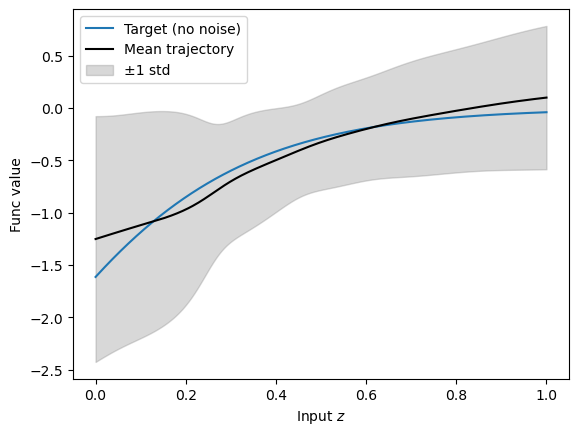

In [121]:
key, subkey = random.split(key)
N = 100
noise = noise_fn(subkey, (N, d_noise))
final_particles = model.apply(params, noise)
ntestpoints = 400
Ztest = jnp.linspace(0, 1, ntestpoints).reshape(-1, 1)
target_values = target_function(Ztest)
predictions = vmap(lambda i: vmap(lambda z: forward_(final_particles[None, i, :], z, unravel_fn))(Ztest))(jnp.arange(N))

mean = predictions.mean(axis=0)
std = predictions.std(axis=0)
plt.plot(Ztest.squeeze(), target_values, label='Target (no noise)')
plt.plot(Ztest.squeeze(), mean, color="k", label="Mean trajectory")
plt.fill_between(Ztest.squeeze(), mean - std, mean + std,
                 color="gray", alpha=0.3, label="±1 std")
# plt.heatmap(predictions, cmap="viridis", cbar=True)

# plt.plot(Ztest, prediction, label='Prediction')
plt.xlabel('Input $z$')
plt.ylabel('Func value')
# plt.title('Learned function for step size eta: {0:.3e}'.format(etas[i_eta]))
plt.legend()
plt.show()

In [108]:
X_fin = final_particles

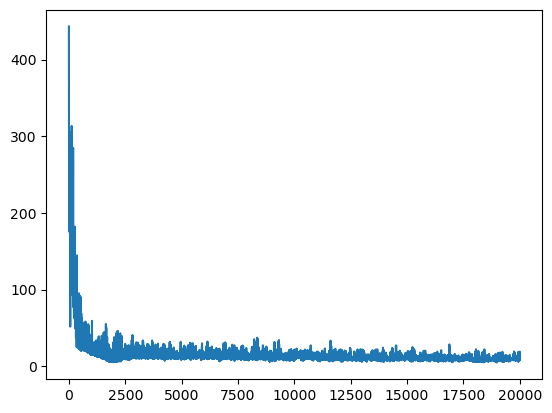

In [109]:

plt.plot(KGD_values)

In [122]:
import pickle

with open("results_heishiro.pkl", "rb") as g:
    results_heishiro = pickle.load(g)

In [123]:
results_heishiro["Variational Inference"]["X_fin"] = F
KGD_values = jnp.array(KGD_values)
results_heishiro["Variational Inference"]["KGD_values"] = jnp.sqrt(KGD_values)

In [124]:
import pickle

with open("results_heishiro.pkl", "wb") as g:
    pickle.dump(results_heishiro, g)